# Final Launch vs. Launch + Weather Comparison

This notebook is the final synthesis of the launch-failure modeling work. Instead of
running another broad exploratory cycle, it uses the main lessons from the earlier
notebooks and compares the strongest **launch-only** model against the strongest
**launch + weather** model.

The target is `is_failure_or_partial`, where:

- `1` means a failed or partially failed launch
- `0` means a successful launch

The earlier notebooks established five key points:

1. the provided `data_split` is effectively chronological
2. tuning random forests using failure-oriented metrics is much better than relying on
   untuned majority-class behavior
3. split-safe historical reliability features are the strongest source of lift
4. weather contains some signal, but broad weather blocks can be noisy
5. threshold tuning matters because this is an imbalanced failure-detection problem

This final notebook therefore does four things:

1. builds the strongest launch feature set using row-wise engineering plus historical
   reliability features
2. runs a compact validation-stage weather subset selection step
3. compares the final launch-only and launch + weather models with the same evaluation
   framework
4. reports both ranking metrics and operational-threshold metrics on the untouched test set

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

ROOT = Path.cwd()
if not (ROOT / "launch_modeling_base_with_weather.csv").exists() and (
    ROOT.parent / "launch_modeling_base_with_weather.csv"
).exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "launch_modeling_base_with_weather.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
TARGET_COL = "is_failure_or_partial"

## Load and Sort the Modeling Table

The notebook starts from the same cleaned launch-level table used throughout the project.
The rows are sorted chronologically because both the split verification and the rolling
historical features depend on time order being explicit.

In [2]:
df = pd.read_csv(DATA_PATH)
df["launch_dt"] = pd.to_datetime(df["launch_time_utc"], errors="coerce", utc=True)
df = df.sort_values(["launch_dt", "Launch Id"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nSplit counts:")
print(df["data_split"].value_counts().sort_index())
print("\nFailure share by split:")
print(df.groupby("data_split")[TARGET_COL].mean().round(4))

df.head()

Dataset shape: 6,168 rows x 89 columns

Split counts:
data_split
test           926
train         4317
validation     925
Name: count, dtype: int64

Failure share by split:
data_split
test          0.0594
train         0.0996
validation    0.0616
Name: is_failure_or_partial, dtype: float64


,Launch Id,launch_time_utc,launch_date,launch_year,launch_month,launch_month_name,launch_quarter,launch_dayofweek,launch_hour_utc,launch_decade,Launch Status,is_success,is_failure_or_partial,Launch Suborbital,is_suborbital,Rocket Name,Rocket Organisation,company_country,company_ownership,Rocket Price,Rocket Price CPI Adjusted,Rocket Payload to LEO,USD/kg to LEO,USD/kg to LEO CPI Adjusted,Location,Country,Country_Code,Operator,Launch Site,Comb Launch Site,facility_group,Lat,Lon,Launch Site Lat,Launch Site Lon,Comb Launch Site Lat,Comb Launch Site Lon,facility_lat,facility_lon,facility_coordinate_source,payload_count,mission_mass,mission_rows,config_status,config_price_musd_text_parsed,config_liftoff_thrust,config_payload_leo,config_payload_gto,config_stages,config_strap_ons,config_rocket_height,config_fairing_diameter,config_fairing_height,rocket_family,family_success_rate_pct,location_joined,mission_joined,config_joined,company_joined,launch_time_lstd,weather_obs_time_lstd,weather_matched,weather_time_diff_minutes,weather_file_name,weather_station_id,DATE,REPORT_TYPE,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlySeaLevelPressure,HourlyWindSpeed,HourlyWindDirection,hourly_nonnulls,present_weather_rain_flag,present_weather_fog_flag,present_weather_thunder_flag,cloud_cover_broken_or_overcast_flag,short_duration_precip_max,HourlyStationPressure,HourlyRelativeHumidity,HourlyAltimeterSetting,HourlyPrecipitation,HourlyVisibility,HourlyWindGustSpeed,HourlyWetBulbTemperature,HourlyPresentWeatherType,HourlySkyConditions,data_split,launch_dt
0,590,1957-10-04 19:28:00+00:00,1957-10-04,1957,10,October,4,4,19,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,84.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-10-05 00:28:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1957-10-04 19:28:00+00:00
1,593,1957-11-03 02:30:00+00:00,1957-11-03,1957,11,November,4,6,2,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,508.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-11-03 07:30:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1957-11-03 02:30:00+00:00
2,845,1957-12-06 16:44:00+00:00,1957-12-06,1957,12,December,4,4,16,1950,Failure,0,1,Orbital,0,Vanguard,US Navy,USA,State,NaN,NaN,10.0,NaN,NaN,"LC-18A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,Cape Canaveral Space Force Station,28.448986,-80.561827,28.489690,-80.563003,28.501081,-80.567792,28.448986,-80.561827,Locations.csv raw Lat/Lon,1.0,2.0,1.0,Retired,NaN,135.0,10.0,NaN,3.0,0.0,23.0,NaN,NaN,Vanguard,22.7,True,True,True,True,1957-12-06 11:44:00,1957-12-06 12:00:00,True,16.0,cape_canaveral_sfs.csv,USW00012868,1957-12-06T12:00:00,SAO,70.0,53.0,30.37,16.0,110.0,11.0,False,False,False,False,NaN,30.35,55.0,NaN,NaN,9.94,NaN,60.0,||00,SCT:03 44,train,1957-12-06 16:44:00+00:00
3,844,1958-02-01 03:47:00+00:00,1958-02-01,1958,2,February,1,5,3,1950,Success,1,0,Orbital,0,Juno I,ABMA,USA,State,NaN,NaN,11.0,NaN,NaN,"LC-26A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy S

## Confirm the Chronological Split

Earlier analysis already suggested that the split is chronological. This notebook keeps
that check visible because the historical reliability features would be invalid if the split
were random.

In [3]:
split_time_summary = (
    df.groupby("data_split")
    .agg(
        min_launch_dt=("launch_dt", "min"),
        max_launch_dt=("launch_dt", "max"),
        rows=("Launch Id", "count"),
    )
    .loc[["train", "validation", "test"]]
)

split_time_summary

,min_launch_dt,max_launch_dt,rows
data_split,,,
train,1957-10-04 19:28:00+00:00,1999-07-08 08:45:00+00:00,4317
validation,1999-07-10 08:45:00+00:00,2012-11-02 21:03:00+00:00,925
test,2012-11-10 21:05:00+00:00,2021-12-30 03:30:00+00:00,926


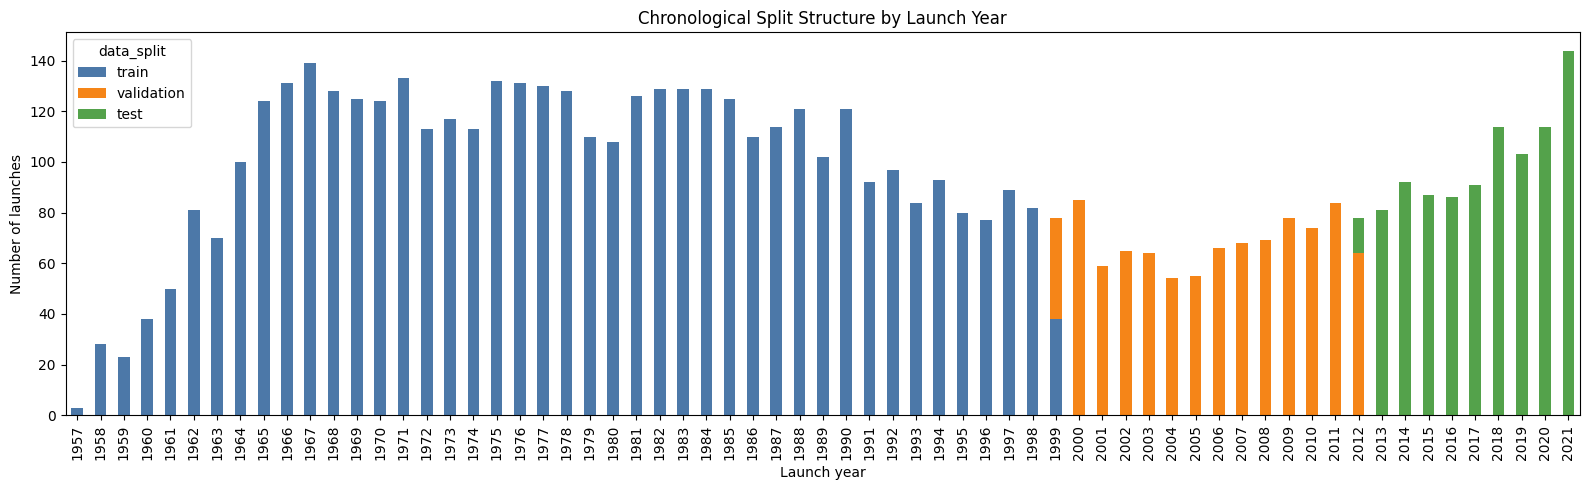

In [4]:
launches_by_year_split = (
    df.groupby(["launch_year", "data_split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "validation", "test"])
)

launches_by_year_split.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 5),
    color=["#4c78a8", "#f58518", "#54a24b"],
)
plt.title("Chronological Split Structure by Launch Year")
plt.xlabel("Launch year")
plt.ylabel("Number of launches")
plt.tight_layout()
plt.show()

**Interpretation**

The split is clearly chronological rather than random. Training runs from **1957-10-04**
to **1999-07-08**, validation covers **1999-07-10** to **2012-11-02**, and test covers
**2012-11-10** to **2021-12-30**.

This is a meaningful design choice rather than a minor data-processing detail. A random
split would make the problem artificially easier because records from the same historical
period would appear in both training and evaluation. By preserving time order, the notebook
treats the task more like a real forecasting exercise in which the model only has access to
past launches when scoring a new one.

This chronological setup also justifies the rolling family, operator, and site history
features used later. Those variables are only defensible if each row is allowed to use
information from earlier launches and not from the future.

## Define the Source Feature Pools

The project has converged on an explicit include-list approach, which makes the final
feature definitions easy to audit. The launch feature pool stays broad because the strongest
gains came from adding better engineered and historical launch features, not from trimming
the launch columns aggressively.

The weather side starts from three groups:

- raw weather variables
- row-wise engineered weather variables
- site-relative weather anomaly variables

A later validation-stage ablation step will decide which weather subset to keep in the
final launch + weather model.

In [5]:
launch_source_features = [
    "launch_year",
    "launch_month",
    "launch_month_name",
    "launch_quarter",
    "launch_dayofweek",
    "launch_hour_utc",
    "launch_decade",
    "Launch Suborbital",
    "is_suborbital",
    "Rocket Name",
    "Rocket Organisation",
    "company_country",
    "company_ownership",
    "Rocket Price CPI Adjusted",
    "Rocket Payload to LEO",
    "USD/kg to LEO CPI Adjusted",
    "Location",
    "Country",
    "Country_Code",
    "Operator",
    "Launch Site",
    "Comb Launch Site",
    "facility_group",
    "Lat",
    "Lon",
    "Launch Site Lat",
    "Launch Site Lon",
    "Comb Launch Site Lat",
    "Comb Launch Site Lon",
    "facility_lat",
    "facility_lon",
    "payload_count",
    "mission_mass",
    "mission_rows",
    "config_price_musd_text_parsed",
    "config_liftoff_thrust",
    "config_payload_leo",
    "config_payload_gto",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "config_fairing_diameter",
    "config_fairing_height",
    "rocket_family",
]

raw_weather_features = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "present_weather_thunder_flag",
    "cloud_cover_broken_or_overcast_flag",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
]

engineered_weather_features = [
    "temperature_dewpoint_spread",
    "wind_u_component",
    "wind_v_component",
    "low_visibility_flag",
    "high_humidity_flag",
    "precipitation_any_flag",
    "storm_signal_flag",
]

site_relative_weather_features = [
    "site_temp_anomaly",
    "site_temp_zscore",
    "site_windspeed_anomaly",
    "site_windspeed_zscore",
    "site_humidity_anomaly",
    "site_humidity_zscore",
    "site_visibility_anomaly",
    "site_visibility_zscore",
    "site_temp_spread_anomaly",
    "site_temp_spread_zscore",
    "site_precip_prior_rate",
    "site_precip_anomaly",
    "site_storm_prior_rate",
    "site_storm_anomaly",
    "site_low_visibility_prior_rate",
    "site_low_visibility_anomaly",
    "site_high_humidity_prior_rate",
    "site_high_humidity_anomaly",
    "site_weather_unusual_count",
    "site_weather_any_large_anomaly_flag",
]

all_expected_columns = launch_source_features + raw_weather_features
missing_expected_columns = [col for col in all_expected_columns if col not in df.columns]
if missing_expected_columns:
    raise ValueError(f"Missing expected source columns: {missing_expected_columns}")

## Feature Engineering

The final launch model uses two kinds of non-weather feature engineering:

- **row-wise engineered launch features**, which use only values from the same launch row
- **split-safe historical reliability features**, which use only launches that happened
  earlier in time

On the weather side, the notebook keeps both:

- row-wise weather features
- site-relative anomaly features that compare current weather to what is historically
  normal at that site

In [6]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan)


def add_rowwise_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    engineered = df.copy()

    engineered["launch_month_sin"] = np.sin(2 * np.pi * engineered["launch_month"] / 12)
    engineered["launch_month_cos"] = np.cos(2 * np.pi * engineered["launch_month"] / 12)
    engineered["launch_dayofweek_sin"] = np.sin(2 * np.pi * engineered["launch_dayofweek"] / 7)
    engineered["launch_dayofweek_cos"] = np.cos(2 * np.pi * engineered["launch_dayofweek"] / 7)
    engineered["launch_hour_sin"] = np.sin(2 * np.pi * engineered["launch_hour_utc"] / 24)
    engineered["launch_hour_cos"] = np.cos(2 * np.pi * engineered["launch_hour_utc"] / 24)

    engineered["rocket_price_log"] = np.log1p(engineered["Rocket Price CPI Adjusted"].clip(lower=0))
    engineered["rocket_payload_log"] = np.log1p(engineered["Rocket Payload to LEO"].clip(lower=0))
    engineered["mission_mass_log"] = np.log1p(engineered["mission_mass"].clip(lower=0))

    engineered["payloads_per_mission_row"] = safe_divide(
        engineered["payload_count"],
        engineered["mission_rows"],
    )
    engineered["mission_mass_per_payload"] = safe_divide(
        engineered["mission_mass"],
        engineered["payload_count"],
    )
    engineered["price_per_payload_kg"] = safe_divide(
        engineered["Rocket Price CPI Adjusted"],
        engineered["Rocket Payload to LEO"],
    )
    engineered["price_per_mission_kg"] = safe_divide(
        engineered["Rocket Price CPI Adjusted"],
        engineered["mission_mass"],
    )
    engineered["thrust_to_leo_payload_ratio"] = safe_divide(
        engineered["config_liftoff_thrust"],
        engineered["config_payload_leo"],
    )
    engineered["mission_to_leo_capacity_ratio"] = safe_divide(
        engineered["mission_mass"],
        engineered["config_payload_leo"],
    )
    engineered["gto_to_leo_capacity_ratio"] = safe_divide(
        engineered["config_payload_gto"],
        engineered["config_payload_leo"],
    )
    engineered["rocket_height_to_fairing_height_ratio"] = safe_divide(
        engineered["config_rocket_height"],
        engineered["config_fairing_height"],
    )
    engineered["fairing_volume_proxy"] = (
        engineered["config_fairing_diameter"] ** 2
    ) * engineered["config_fairing_height"]
    engineered["total_stage_elements"] = (
        engineered["config_stages"].fillna(0) + engineered["config_strap_ons"].fillna(0)
    )

    engineered["temperature_dewpoint_spread"] = (
        engineered["HourlyDryBulbTemperature"] - engineered["HourlyDewPointTemperature"]
    )
    wind_direction_radians = np.deg2rad(engineered["HourlyWindDirection"])
    engineered["wind_u_component"] = engineered["HourlyWindSpeed"] * np.cos(wind_direction_radians)
    engineered["wind_v_component"] = engineered["HourlyWindSpeed"] * np.sin(wind_direction_radians)
    engineered["low_visibility_flag"] = (engineered["HourlyVisibility"].fillna(99) < 5).astype(int)
    engineered["high_humidity_flag"] = (engineered["HourlyRelativeHumidity"].fillna(-1) >= 85).astype(int)
    engineered["precipitation_any_flag"] = (
        engineered["present_weather_rain_flag"].astype(str) == "True"
    ).astype(int)
    engineered["storm_signal_flag"] = (
        (engineered["present_weather_thunder_flag"].astype(str) == "True")
        | (
            (engineered["HourlyWindSpeed"].fillna(0) >= 20)
            & (engineered["present_weather_rain_flag"].astype(str) == "True")
        )
    ).astype(int)

    return engineered


def add_site_relative_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    site_weather = df.copy().sort_values(["launch_dt", "Launch Id"]).reset_index(drop=True)

    numeric_site_weather_cols = {
        "HourlyDryBulbTemperature": "site_temp",
        "HourlyWindSpeed": "site_windspeed",
        "HourlyRelativeHumidity": "site_humidity",
        "HourlyVisibility": "site_visibility",
        "temperature_dewpoint_spread": "site_temp_spread",
    }

    for col, prefix in numeric_site_weather_cols.items():
        group_obj = site_weather.groupby("facility_group", dropna=False)[col]
        prior_mean = group_obj.transform(lambda series: series.shift().expanding(min_periods=5).mean())
        prior_std = group_obj.transform(lambda series: series.shift().expanding(min_periods=5).std())

        site_weather[f"{prefix}_prior_mean"] = prior_mean
        site_weather[f"{prefix}_prior_std"] = prior_std
        site_weather[f"{prefix}_anomaly"] = site_weather[col] - prior_mean
        site_weather[f"{prefix}_zscore"] = safe_divide(site_weather[f"{prefix}_anomaly"], prior_std)
        site_weather[f"{prefix}_abs_zscore"] = site_weather[f"{prefix}_zscore"].abs()

    binary_site_weather_cols = {
        "precipitation_any_flag": "site_precip",
        "storm_signal_flag": "site_storm",
        "low_visibility_flag": "site_low_visibility",
        "high_humidity_flag": "site_high_humidity",
    }

    for col, prefix in binary_site_weather_cols.items():
        group_obj = site_weather.groupby("facility_group", dropna=False)[col]
        prior_rate = group_obj.transform(lambda series: series.shift().expanding(min_periods=5).mean())
        site_weather[f"{prefix}_prior_rate"] = prior_rate
        site_weather[f"{prefix}_anomaly"] = site_weather[col] - prior_rate

    abs_zscore_cols = [f"{prefix}_abs_zscore" for prefix in numeric_site_weather_cols.values()]
    site_weather["site_weather_unusual_count"] = site_weather[abs_zscore_cols].ge(1.5).sum(axis=1)
    site_weather["site_weather_any_large_anomaly_flag"] = (
        site_weather["site_weather_unusual_count"] >= 1
    ).astype(int)

    return site_weather


def add_historical_features(df: pd.DataFrame) -> pd.DataFrame:
    historical = df.copy().sort_values(["launch_dt", "Launch Id"]).reset_index(drop=True)

    for group_col, prefix in [
        ("rocket_family", "family"),
        ("Operator", "operator"),
        ("facility_group", "site"),
    ]:
        group_obj = historical.groupby(group_col, dropna=False)
        historical[f"{prefix}_prior_launch_count"] = group_obj.cumcount()
        historical[f"{prefix}_prior_failure_count"] = group_obj[TARGET_COL].cumsum() - historical[TARGET_COL]
        historical[f"{prefix}_prior_failure_rate"] = safe_divide(
            historical[f"{prefix}_prior_failure_count"],
            historical[f"{prefix}_prior_launch_count"].replace(0, np.nan),
        ).fillna(0)
        historical[f"{prefix}_days_since_last_launch"] = (
            group_obj["launch_dt"].diff().dt.total_seconds() / 86400
        )

    return historical


df_engineered = add_historical_features(
    add_site_relative_weather_features(
        add_rowwise_engineered_features(df)
    )
)

### Engineered Variable Reference

This section defines the engineered variables created in the notebook so the modeling
pipeline is easier to describe in a final report.

**Row-wise engineered launch features**

- `launch_month_sin`, `launch_month_cos`: cyclical encoding of launch month so December and
  January are treated as close in time rather than far apart numerically.
- `launch_dayofweek_sin`, `launch_dayofweek_cos`: cyclical encoding of day of week.
- `launch_hour_sin`, `launch_hour_cos`: cyclical encoding of launch hour in UTC.
- `rocket_price_log`: `log(1 + Rocket Price CPI Adjusted)` to reduce skew in launch cost.
- `rocket_payload_log`: `log(1 + Rocket Payload to LEO)` to reduce skew in payload
  capacity.
- `mission_mass_log`: `log(1 + mission_mass)` to reduce skew in mission mass.
- `payloads_per_mission_row`: payload count divided by mission rows, used as a simple
  density measure for how many payloads are attached to the mission record.
- `mission_mass_per_payload`: mission mass divided by payload count.
- `price_per_payload_kg`: rocket price divided by LEO payload capacity, a rough cost per kg
  capacity measure.
- `price_per_mission_kg`: rocket price divided by actual mission mass.
- `thrust_to_leo_payload_ratio`: liftoff thrust divided by nominal LEO payload capacity.
- `mission_to_leo_capacity_ratio`: mission mass divided by nominal LEO payload capacity,
  used as a rough loading/intensity measure.
- `gto_to_leo_capacity_ratio`: GTO payload capacity divided by LEO payload capacity.
- `rocket_height_to_fairing_height_ratio`: rocket height divided by fairing height.
- `fairing_volume_proxy`: `fairing_diameter^2 * fairing_height`, a simple proxy for fairing
  size.
- `total_stage_elements`: number of stages plus strap-on boosters.

**Row-wise engineered weather features**

- `temperature_dewpoint_spread`: air temperature minus dew point; smaller spreads often
  indicate more saturated air.
- `wind_u_component`: east-west wind component derived from wind speed and direction.
- `wind_v_component`: north-south wind component derived from wind speed and direction.
- `low_visibility_flag`: indicator for visibility below 5 miles.
- `high_humidity_flag`: indicator for relative humidity at or above 85%.
- `precipitation_any_flag`: indicator that rain is present.
- `storm_signal_flag`: indicator for thunder or the combination of rain and high wind.

**Site-relative weather features**

The site-relative features compare the current launch weather to what was historically normal
at the same `facility_group`, using only prior launches at that site.

- `site_temp_anomaly`, `site_windspeed_anomaly`, `site_humidity_anomaly`,
  `site_visibility_anomaly`, `site_temp_spread_anomaly`: current value minus the prior
  same-site mean for temperature, wind speed, humidity, visibility, and
  temperature-dewpoint spread.
- `site_temp_zscore`, `site_windspeed_zscore`, `site_humidity_zscore`,
  `site_visibility_zscore`, `site_temp_spread_zscore`: anomaly divided by the prior
  same-site standard deviation, showing how unusual the current reading is relative to that
  site's history.
- `site_precip_prior_rate`, `site_storm_prior_rate`, `site_low_visibility_prior_rate`,
  `site_high_humidity_prior_rate`: prior same-site frequency of rain, storm signal, low
  visibility, and high humidity.
- `site_precip_anomaly`, `site_storm_anomaly`, `site_low_visibility_anomaly`,
  `site_high_humidity_anomaly`: difference between the current binary condition and the
  historical same-site rate for that condition.
- `site_weather_unusual_count`: count of numeric site-relative weather measures with an
  absolute z-score of at least 1.5.
- `site_weather_any_large_anomaly_flag`: indicator that at least one numeric weather
  variable is meaningfully unusual for that site.

The notebook also computes helper baseline columns such as `site_temp_prior_mean`,
`site_temp_prior_std`, and analogous same-site historical summaries for the other numeric
weather variables. Those columns are used to construct anomalies and z-scores, but they are
not part of the final candidate weather feature set.

**Historical reliability features**

These are built separately for `rocket_family`, `Operator`, and `facility_group`, always
using only launches that occurred earlier in time.

- `family_prior_launch_count`, `operator_prior_launch_count`, `site_prior_launch_count`:
  number of prior launches for the family, operator, or site.
- `family_prior_failure_count`, `operator_prior_failure_count`,
  `site_prior_failure_count`: number of prior failed or partially failed launches for the
  family, operator, or site.
- `family_prior_failure_rate`, `operator_prior_failure_rate`,
  `site_prior_failure_rate`: prior failure count divided by prior launch count.
- `family_days_since_last_launch`, `operator_days_since_last_launch`,
  `site_days_since_last_launch`: days since the last launch for the same family, operator,
  or site.

In [7]:
engineered_launch_features = [
    "launch_month_sin",
    "launch_month_cos",
    "launch_dayofweek_sin",
    "launch_dayofweek_cos",
    "launch_hour_sin",
    "launch_hour_cos",
    "rocket_price_log",
    "rocket_payload_log",
    "mission_mass_log",
    "payloads_per_mission_row",
    "mission_mass_per_payload",
    "price_per_payload_kg",
    "price_per_mission_kg",
    "thrust_to_leo_payload_ratio",
    "mission_to_leo_capacity_ratio",
    "gto_to_leo_capacity_ratio",
    "rocket_height_to_fairing_height_ratio",
    "fairing_volume_proxy",
    "total_stage_elements",
]

historical_features = [
    "family_prior_launch_count",
    "family_prior_failure_count",
    "family_prior_failure_rate",
    "family_days_since_last_launch",
    "operator_prior_launch_count",
    "operator_prior_failure_count",
    "operator_prior_failure_rate",
    "operator_days_since_last_launch",
    "site_prior_launch_count",
    "site_prior_failure_count",
    "site_prior_failure_rate",
    "site_days_since_last_launch",
]

launch_final_features = (
    launch_source_features
    + engineered_launch_features
    + historical_features
)

all_weather_candidate_features = (
    raw_weather_features
    + engineered_weather_features
    + site_relative_weather_features
)

feature_summary = pd.DataFrame(
    {
        "feature_set": [
            "launch_final_features",
            "all_weather_candidate_features",
        ],
        "num_features": [
            len(launch_final_features),
            len(all_weather_candidate_features),
        ],
    }
)

feature_summary

,feature_set,num_features
0,launch_final_features,75
1,all_weather_candidate_features,38


## Split the Data

The split structure is fixed throughout the notebook:

- `train` is used to fit and tune
- `validation` is used for weather-subset selection and threshold selection
- `test` is only used for the final model comparison

In [8]:
train_mask = df_engineered["data_split"].eq("train")
val_mask = df_engineered["data_split"].eq("validation")
test_mask = df_engineered["data_split"].eq("test")
trainval_mask = df_engineered["data_split"].isin(["train", "validation"])

y_train = df_engineered.loc[train_mask, TARGET_COL]
y_val = df_engineered.loc[val_mask, TARGET_COL]
y_test = df_engineered.loc[test_mask, TARGET_COL]
y_trainval = df_engineered.loc[trainval_mask, TARGET_COL]

## Modeling Helpers

The final comparison keeps the model family fixed as random forest so that all gains can be
interpreted as coming from better features, better weather selection, and better threshold
use rather than from changing the model class.

The tuning target is **average precision**, which is more aligned with the failure-detection
objective than plain accuracy.

In [9]:
def build_pipeline(X: pd.DataFrame, rf_params: dict | None = None) -> Pipeline:
    rf_params = rf_params or {}

    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                        (
                            "to_string",
                            FunctionTransformer(
                                lambda data: data.astype(str),
                                feature_names_out="one-to-one",
                            ),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

    model_defaults = {
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "class_weight": "balanced_subsample",
    }
    model_defaults.update(rf_params)

    model = RandomForestClassifier(**model_defaults)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def run_random_search(X_train: pd.DataFrame, X_val: pd.DataFrame, y_train: pd.Series, y_val: pd.Series):
    X_dev = pd.concat([X_train, X_val], axis=0)
    y_dev = pd.concat([y_train, y_val], axis=0)
    split_index = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
    predefined_split = PredefinedSplit(test_fold=split_index)

    param_distributions = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 12, 16, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.4],
        "model__max_leaf_nodes": [32, 64, 128, None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    }

    search = RandomizedSearchCV(
        estimator=build_pipeline(X_train),
        param_distributions=param_distributions,
        n_iter=12,
        scoring="average_precision",
        cv=predefined_split,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=False,
        verbose=0,
    )
    search.fit(X_dev, y_dev)

    best_params = {key.replace("model__", ""): value for key, value in search.best_params_.items()}

    results = (
        pd.DataFrame(search.cv_results_)
        .sort_values("rank_test_score")
        .loc[
            :,
            [
                "rank_test_score",
                "mean_test_score",
                "param_model__n_estimators",
                "param_model__max_depth",
                "param_model__min_samples_split",
                "param_model__min_samples_leaf",
                "param_model__max_features",
                "param_model__max_leaf_nodes",
                "param_model__class_weight",
            ],
        ]
        .rename(columns={"mean_test_score": "validation_average_precision"})
    )
    results["validation_average_precision"] = results["validation_average_precision"].round(4)

    return best_params, results


def fit_model(X_train: pd.DataFrame, y_train: pd.Series, rf_params: dict | None = None):
    model = build_pipeline(X_train, rf_params=rf_params)
    model.fit(X_train, y_train)
    return model


def top_decile_capture(y_true: pd.Series, scores: np.ndarray, share: float = 0.10) -> float:
    ranked = pd.DataFrame({"y_true": y_true.to_numpy(), "score": scores}).sort_values("score", ascending=False)
    cutoff = max(1, int(np.ceil(len(ranked) * share)))
    captured_failures = ranked.head(cutoff)["y_true"].sum()
    total_failures = ranked["y_true"].sum()
    if total_failures == 0:
        return np.nan
    return captured_failures / total_failures


def threshold_metrics(y_true: pd.Series, scores: np.ndarray, threshold: float, model_name: str, split_name: str, operating_point: str):
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "split": split_name,
        "operating_point": operating_point,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "failure_precision": precision_score(y_true, y_pred, zero_division=0),
        "failure_recall": recall_score(y_true, y_pred, zero_division=0),
        "success_recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "average_precision": average_precision_score(y_true, scores),
        "brier_score": brier_score_loss(y_true, scores),
        "top_decile_capture": top_decile_capture(y_true, scores),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
    }


def metrics_frame(metric_rows: list[dict]) -> pd.DataFrame:
    metric_cols = [
        "threshold",
        "accuracy",
        "balanced_accuracy",
        "failure_precision",
        "failure_recall",
        "success_recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier_score",
        "top_decile_capture",
    ]
    out = pd.DataFrame(metric_rows)
    out[metric_cols] = out[metric_cols].round(4)
    return out


def operating_point_table(y_true: pd.Series, scores: np.ndarray, model_name: str, precision_floor: float = 0.25) -> pd.DataFrame:
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, scores)
    candidate_thresholds = np.unique(np.clip(np.r_[0.5, thresholds], 0, 1))

    rows = []
    for threshold in candidate_thresholds:
        y_pred = (scores >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "failure_precision": precision_score(y_true, y_pred, zero_division=0),
                "failure_recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            }
        )

    threshold_df = pd.DataFrame(rows).drop_duplicates(subset=["threshold"]).sort_values("threshold").reset_index(drop=True)
    default_row = threshold_df.iloc[(threshold_df["threshold"] - 0.5).abs().argmin()].copy()
    default_row["operating_point"] = "default_0_50"

    best_f1_row = threshold_df.sort_values(["f1", "balanced_accuracy"], ascending=False).iloc[0].copy()
    best_f1_row["operating_point"] = "best_validation_f1"

    precision_floor_df = threshold_df.loc[threshold_df["failure_precision"] >= precision_floor]
    if precision_floor_df.empty:
        precision_floor_row = threshold_df.sort_values(["failure_precision", "failure_recall"], ascending=False).iloc[0].copy()
        precision_floor_row["operating_point"] = f"best_available_precision_floor_{precision_floor:.2f}"
    else:
        precision_floor_row = precision_floor_df.sort_values(
            ["failure_recall", "f1", "balanced_accuracy"],
            ascending=False,
        ).iloc[0].copy()
        precision_floor_row["operating_point"] = f"max_recall_at_precision_{precision_floor:.2f}"

    operating_points = pd.DataFrame([default_row, best_f1_row, precision_floor_row])
    operating_points.insert(0, "model", model_name)
    numeric_cols = ["threshold", "failure_precision", "failure_recall", "f1", "balanced_accuracy"]
    operating_points[numeric_cols] = operating_points[numeric_cols].round(4)
    return operating_points


def get_feature_importance_frame(model: Pipeline, top_n: int = 15) -> pd.DataFrame:
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    importances = model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    ).sort_values("importance", ascending=False)
    return importance_df.head(top_n)


def get_source_feature_importance_frame(model: Pipeline) -> pd.DataFrame:
    preprocessor = model.named_steps["preprocessor"]
    importances = model.named_steps["model"].feature_importances_
    rows = []
    position = 0

    for transformer_name, transformer, columns in preprocessor.transformers_:
        if transformer_name == "remainder":
            continue

        if transformer_name == "num":
            for col in columns:
                rows.append({"source_feature": col, "importance": importances[position]})
                position += 1
        elif transformer_name == "cat":
            onehot = transformer.named_steps["onehot"]
            for col, categories in zip(columns, onehot.categories_):
                width = len(categories)
                rows.append(
                    {
                        "source_feature": col,
                        "importance": importances[position: position + width].sum(),
                    }
                )
                position += width

    return (
        pd.DataFrame(rows)
        .groupby("source_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def subset_validation_metrics(
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    y_train: pd.Series,
    y_val: pd.Series,
    rf_params: dict,
    subset_name: str,
) -> dict:
    subset_model = fit_model(X_train, y_train, rf_params=rf_params)
    subset_scores = subset_model.predict_proba(X_val)[:, 1]
    subset_pred = (subset_scores >= 0.5).astype(int)

    return {
        "weather_subset": subset_name,
        "num_weather_features": X_train.shape[1] - len(launch_final_features),
        "validation_average_precision": average_precision_score(y_val, subset_scores),
        "validation_roc_auc": roc_auc_score(y_val, subset_scores),
        "validation_failure_precision": precision_score(y_val, subset_pred, zero_division=0),
        "validation_failure_recall": recall_score(y_val, subset_pred, zero_division=0),
        "validation_f1": f1_score(y_val, subset_pred, zero_division=0),
        "validation_balanced_accuracy": balanced_accuracy_score(y_val, subset_pred),
        "validation_top_decile_capture": top_decile_capture(y_val, subset_scores),
    }

## Tune the Launch-Only Model and the Full Weather Candidate Model

The launch-only model is tuned directly. On the weather side, the notebook first tunes a
model using the full weather candidate field. That full weather model then becomes the basis
for the weather-subset comparison.

In [10]:
launch_train = df_engineered.loc[train_mask, launch_final_features]
launch_val = df_engineered.loc[val_mask, launch_final_features]

full_weather_train = df_engineered.loc[train_mask, launch_final_features + all_weather_candidate_features]
full_weather_val = df_engineered.loc[val_mask, launch_final_features + all_weather_candidate_features]

launch_best_params, launch_search_results = run_random_search(
    launch_train,
    launch_val,
    y_train,
    y_val,
)

weather_best_params, weather_search_results = run_random_search(
    full_weather_train,
    full_weather_val,
    y_train,
    y_val,
)

pd.DataFrame(
    [
        {"model": "Launch-Only", **launch_best_params},
        {"model": "Full Weather Candidate", **weather_best_params},
    ]
)

,model,n_estimators,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth,class_weight
0,Launch-Only,600,5,8,None,0.4,12,balanced
1,Full Weather Candidate,600,5,8,None,0.4,12,balanced


In [11]:
print("Top launch-only candidates ranked by validation average precision:")
display(launch_search_results.head(5))

print("Top full-weather candidates ranked by validation average precision:")
display(weather_search_results.head(5))

Top launch-only candidates ranked by validation average precision:


,rank_test_score,validation_average_precision,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes,param_model__class_weight
1,1,0.3225,600,12,5,8,0.4,None,balanced
2,2,0.3196,400,16,10,8,0.4,None,balanced
9,3,0.3104,600,16,5,2,0.4,128,balanced
6,4,0.3033,200,24,2,4,0.4,64,balanced
10,5,0.2940,200,None,10,1,0.4,64,balanced


Top full-weather candidates ranked by validation average precision:


,rank_test_score,validation_average_precision,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes,param_model__class_weight
1,1,0.3125,600,12,5,8,0.4,None,balanced
2,2,0.3060,400,16,10,8,0.4,None,balanced
9,3,0.2933,600,16,5,2,0.4,128,balanced
10,4,0.2828,200,None,10,1,0.4,64,balanced
6,5,0.2807,200,24,2,4,0.4,64,balanced


## Validation-Stage Weather Subset Selection

This is the main synthesis step for the weather model. Rather than carrying every weather
field into the final comparison, the notebook tests a small set of candidate weather blocks:

- raw weather only
- engineered weather only
- site-relative weather only
- full weather block
- top weather variables ranked by source-level importance

The launch block stays fixed during this step. That keeps the comparison focused on whether
extra weather complexity is actually helping.

In [12]:
full_weather_validation_model = fit_model(
    full_weather_train,
    y_train,
    rf_params=weather_best_params,
)

weather_source_importances = (
    get_source_feature_importance_frame(full_weather_validation_model)
    .loc[
        lambda frame: frame["source_feature"].isin(
            all_weather_candidate_features
        )
    ]
    .reset_index(drop=True)
)

weather_source_importances.head(20)

,source_feature,importance
0,site_high_humidity_anomaly,0.014928
1,site_temp_spread_zscore,0.010306
2,site_precip_prior_rate,0.010083
3,site_humidity_anomaly,0.009704
4,site_temp_spread_anomaly,0.009659
5,site_high_humidity_prior_rate,0.009486
6,site_low_visibility_prior_rate,0.009334
7,HourlySeaLevelPressure,0.009288
8,site_low_visibility_anomaly,0.009146
9,HourlyRelativeHumidity,0.009086


In [13]:
top_5_weather_features = weather_source_importances.head(5)["source_feature"].tolist()
top_10_weather_features = weather_source_importances.head(10)["source_feature"].tolist()
top_15_weather_features = weather_source_importances.head(15)["source_feature"].tolist()

weather_feature_subsets = {
    "full_weather_block": all_weather_candidate_features,
    "raw_weather_only": raw_weather_features,
    "engineered_weather_only": engineered_weather_features,
    "site_relative_weather_only": site_relative_weather_features,
    "top_5_weather_features": top_5_weather_features,
    "top_10_weather_features": top_10_weather_features,
    "top_15_weather_features": top_15_weather_features,
}

weather_subset_validation_rows = []
for subset_name, subset_weather_features in weather_feature_subsets.items():
    subset_train = df_engineered.loc[train_mask, launch_final_features + subset_weather_features]
    subset_val = df_engineered.loc[val_mask, launch_final_features + subset_weather_features]
    weather_subset_validation_rows.append(
        subset_validation_metrics(
            subset_train,
            subset_val,
            y_train,
            y_val,
            rf_params=weather_best_params,
            subset_name=subset_name,
        )
    )

weather_subset_validation_results = pd.DataFrame(weather_subset_validation_rows)
metric_cols = [
    "validation_average_precision",
    "validation_roc_auc",
    "validation_failure_precision",
    "validation_failure_recall",
    "validation_f1",
    "validation_balanced_accuracy",
    "validation_top_decile_capture",
]
weather_subset_validation_results[metric_cols] = weather_subset_validation_results[metric_cols].round(4)

weather_subset_validation_results.sort_values(
    ["validation_average_precision", "validation_roc_auc"],
    ascending=False,
)

,weather_subset,num_weather_features,validation_average_precision,validation_roc_auc,validation_failure_precision,validation_failure_recall,validation_f1,validation_balanced_accuracy,validation_top_decile_capture
4,top_5_weather_features,5,0.3177,0.7627,0.2750,0.3860,0.3212,0.6596,0.4211
6,top_15_weather_features,15,0.3131,0.7663,0.2716,0.3860,0.3188,0.6590,0.4035
0,full_weather_block,38,0.3125,0.7607,0.2614,0.4035,0.3172,0.6643,0.4211
2,engineered_weather_only,7,0.3077,0.7540,0.2740,0.3509,0.3077,0.6449,0.4035
3,site_relative_weather_only,20,0.3075,0.7584,0.2907,0.4386,0.3497,0.6842,0.4386
1,raw_weather_only,11,0.2971,0.7616,0.2892,0.4211,0.3429,0.6765,0.4386
5,top_10_weather_features,10,0.2941,0.7563,0.2683,0.3860,0.3165,0.6584,0.3860


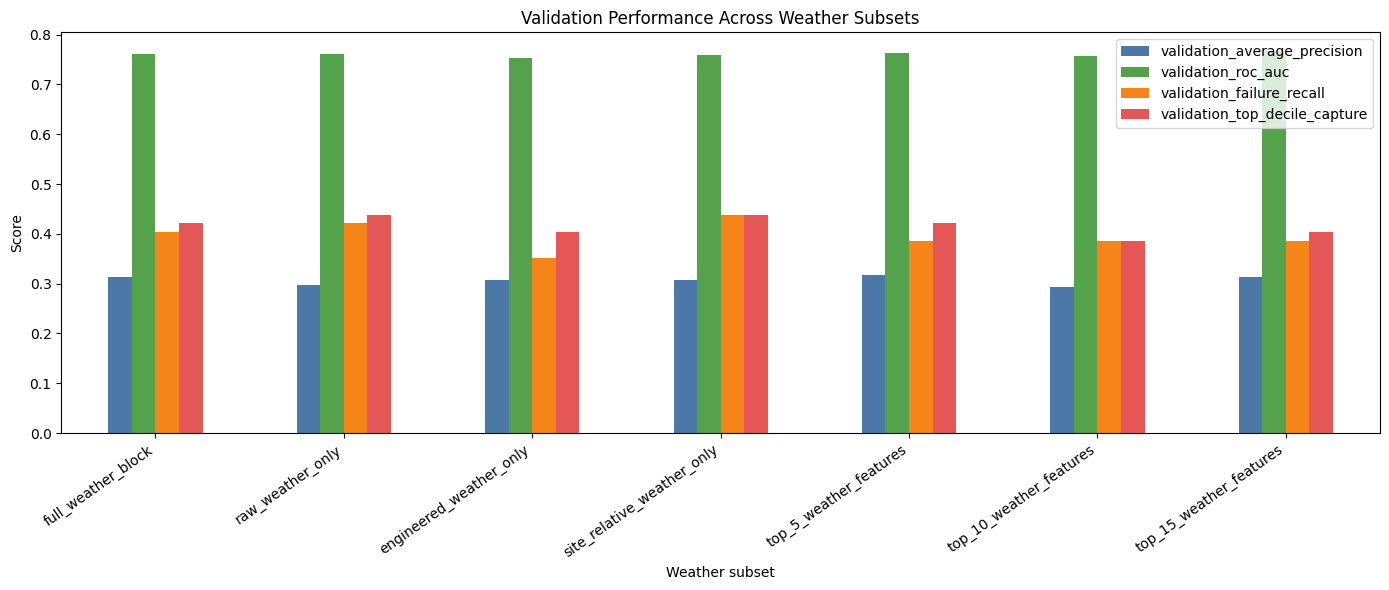

In [14]:
weather_subset_validation_results.set_index("weather_subset")[
    [
        "validation_average_precision",
        "validation_roc_auc",
        "validation_failure_recall",
        "validation_top_decile_capture",
    ]
].plot(
    kind="bar",
    figsize=(14, 6),
    color=["#4c78a8", "#54a24b", "#f58518", "#e45756"],
)
plt.title("Validation Performance Across Weather Subsets")
plt.xlabel("Weather subset")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [15]:
selected_weather_subset_name = (
    weather_subset_validation_results
    .sort_values(["validation_average_precision", "validation_roc_auc"], ascending=False)
    .iloc[0]["weather_subset"]
)
selected_weather_features = weather_feature_subsets[selected_weather_subset_name]

print("Selected weather subset:", selected_weather_subset_name)
print("Selected weather-only features:")
print(selected_weather_features)

Selected weather subset: top_5_weather_features
Selected weather-only features:
['site_high_humidity_anomaly', 'site_temp_spread_zscore', 'site_precip_prior_rate', 'site_humidity_anomaly', 'site_temp_spread_anomaly']


**Interpretation**

The weather subset experiment reinforces an important point from the final comparison: more
weather variables do not automatically produce a better weather model. The selected subset is
**`top_5_weather_features`**, which keeps only five site-relative variables:

- `site_high_humidity_anomaly`
- `site_temp_spread_zscore`
- `site_precip_prior_rate`
- `site_humidity_anomaly`
- `site_temp_spread_anomaly`

On validation, this compact subset reaches **average precision = 0.3177** and
**ROC AUC = 0.7627**. The full weather block is slightly worse on the primary
selection metric, with **average precision = 0.3125** and **ROC AUC = 0.7607**.

Some broader weather subsets do better on individual secondary metrics. For example,
`site_relative_weather_only` has the highest validation balanced accuracy (**0.6842**)
and top-decile capture (**0.4386**), while `top_15_weather_features` has the highest
ROC AUC (**0.7663**). However, because the notebook selects weather features by
validation average precision, the final weather model uses the compact top-5 subset.

This supports a modest interpretation of the weather signal. Weather is not irrelevant,
but the useful signal appears concentrated in a small number of site-relative variables
rather than in a large undifferentiated weather block.


## Fit the Final Validation Models

At this point the comparison is clean:

- the **launch-only** model uses the strongest non-weather feature set
- the **launch + weather** model uses the same launch block plus the best-performing weather
  subset from validation

In [16]:
weather_final_features = launch_final_features + selected_weather_features

final_validation_models = {
    "Launch-Only": fit_model(
        launch_train,
        y_train,
        rf_params=launch_best_params,
    ),
    "Launch + Weather": fit_model(
        df_engineered.loc[train_mask, weather_final_features],
        y_train,
        rf_params=weather_best_params,
    ),
}

validation_scores = {
    "Launch-Only": final_validation_models["Launch-Only"].predict_proba(launch_val)[:, 1],
    "Launch + Weather": final_validation_models["Launch + Weather"].predict_proba(
        df_engineered.loc[val_mask, weather_final_features]
    )[:, 1],
}

## Validation Comparison and Threshold Analysis

The validation split serves two separate purposes here:

- compare the launch-only and compact launch + weather models before touching the test set
- choose operating thresholds that can be carried forward to the final test comparison

The first table evaluates both models at the default `0.5` threshold. The second table
shows three validation operating points for each model:

- `default_0_50`: the standard `0.5` probability threshold
- `best_validation_f1`: the threshold with the best validation F1 score
- `max_recall_at_precision_0.25`: the threshold that maximizes validation recall while
  keeping failure precision at or above `0.25`

The final test comparison carries forward `default_0_50` and
`max_recall_at_precision_0.25`. The best-F1 threshold is shown as a diagnostic but is not
used as the main operational threshold in the final comparison.


In [17]:
validation_default_metrics = metrics_frame(
    [
        threshold_metrics(
            y_val,
            validation_scores["Launch-Only"],
            threshold=0.5,
            model_name="Launch-Only",
            split_name="validation",
            operating_point="default_0_50",
        ),
        threshold_metrics(
            y_val,
            validation_scores["Launch + Weather"],
            threshold=0.5,
            model_name="Launch + Weather",
            split_name="validation",
            operating_point="default_0_50",
        ),
    ]
)

validation_default_metrics.sort_values(["average_precision", "roc_auc"], ascending=False)

,model,split,operating_point,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,average_precision,brier_score,top_decile_capture,tn,fp,fn,tp
0,Launch-Only,validation,default_0_50,0.5,0.9135,0.6753,0.3333,0.4035,0.9470,0.3651,0.7761,0.3225,0.1218,0.4211,822,46,34,23
1,Launch + Weather,validation,default_0_50,0.5,0.8995,0.6596,0.2750,0.3860,0.9332,0.3212,0.7627,0.3177,0.1242,0.4211,810,58,35,22


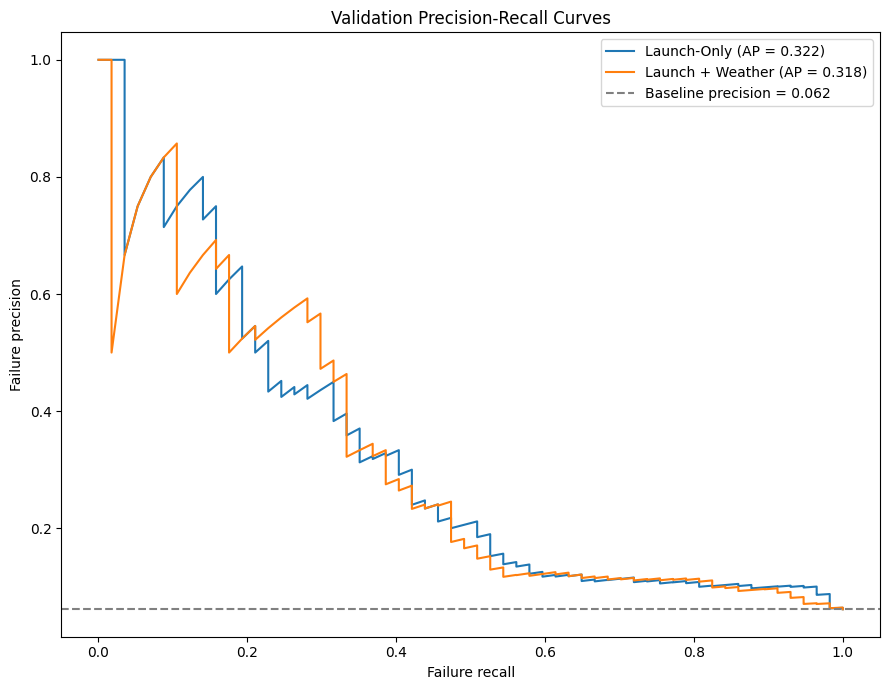

In [18]:
plt.figure(figsize=(9, 7))
for model_name, scores in validation_scores.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, scores)
    avg_precision = average_precision_score(y_val, scores)
    plt.plot(recall_curve, precision_curve, label=f"{model_name} (AP = {avg_precision:.3f})")

baseline_precision = y_val.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label=f"Baseline precision = {baseline_precision:.3f}")
plt.xlabel("Failure recall")
plt.ylabel("Failure precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
validation_operating_points = pd.concat(
    [
        operating_point_table(y_val, validation_scores["Launch-Only"], model_name="Launch-Only", precision_floor=0.25),
        operating_point_table(y_val, validation_scores["Launch + Weather"], model_name="Launch + Weather", precision_floor=0.25),
    ],
    ignore_index=True,
)

validation_operating_points

,model,threshold,failure_precision,failure_recall,f1,balanced_accuracy,operating_point
0,Launch-Only,0.5000,0.3333,0.4035,0.3651,0.6753,default_0_50
1,Launch-Only,0.5535,0.4500,0.3158,0.3711,0.6452,best_validation_f1
2,Launch-Only,0.4940,0.3000,0.4211,0.3504,0.6783,max_recall_at_precision_0.25
3,Launch + Weather,0.5000,0.2750,0.3860,0.3212,0.6596,default_0_50
4,Launch + Weather,0.5867,0.5667,0.2982,0.3908,0.6416,best_validation_f1
5,Launch + Weather,0.4952,0.2727,0.4211,0.3310,0.6737,max_recall_at_precision_0.25


**Interpretation**

On the validation split, the comparison is close but the **Launch-Only** model is the
stronger ranking model. At the default threshold it reaches **ROC AUC = 0.7761** and
**average precision = 0.3225**, while **Launch + Weather** reaches
**ROC AUC = 0.7627** and **average precision = 0.3177**.

At the default `0.5` threshold, launch-only also has better failure precision
(**0.3333** vs **0.2750**) and slightly better failure recall (**0.4035** vs
**0.3860**).

The threshold table shows the expected precision-recall tradeoff. For both models, the
`best_validation_f1` threshold raises precision but lowers recall. Launch-only moves to
**precision = 0.4500** and **recall = 0.3158** at threshold **0.5535**. Launch + Weather
moves to **precision = 0.5667** and **recall = 0.2982** at threshold **0.5867**.

The `max_recall_at_precision_0.25` operating point instead prioritizes recall while keeping
precision above the minimum floor. It gives launch-only **precision = 0.3000** and
**recall = 0.4211** at threshold **0.4940**, and gives Launch + Weather
**precision = 0.2727** and **recall = 0.4211** at threshold **0.4952**. This is why that
operating point is carried into the final test comparison: it is more aligned with a
failure-screening use case than the higher-precision, lower-recall best-F1 threshold.


The notebook carries two operating points into the final test comparison for each model:

- `default_0_50`
- `max_recall_at_precision_0.25`

The `best_validation_f1` threshold is useful for understanding the validation tradeoff, but
it is not the main final operating point. For this project, the more practical threshold is
`max_recall_at_precision_0.25` because the use case is closer to failure screening: catch
more failures while keeping false alarms somewhat constrained.


## Refit the Final Models on Train + Validation

Once the validation-stage feature and threshold choices are fixed, the final model versions
are fit on `train + validation`. The holdout test split remains untouched until this point.

In [20]:
launch_trainval = df_engineered.loc[trainval_mask, launch_final_features]
weather_trainval = df_engineered.loc[trainval_mask, weather_final_features]
launch_test = df_engineered.loc[test_mask, launch_final_features]
weather_test = df_engineered.loc[test_mask, weather_final_features]

final_models = {
    "Launch-Only": fit_model(
        launch_trainval,
        y_trainval,
        rf_params=launch_best_params,
    ),
    "Launch + Weather": fit_model(
        weather_trainval,
        y_trainval,
        rf_params=weather_best_params,
    ),
}

test_scores = {
    "Launch-Only": final_models["Launch-Only"].predict_proba(launch_test)[:, 1],
    "Launch + Weather": final_models["Launch + Weather"].predict_proba(weather_test)[:, 1],
}

## Final Test Comparison

The final comparison has two layers:

- **ranking quality**: ROC AUC, average precision, top-decile capture
- **operational performance**: failure precision and failure recall at the selected
  threshold

In [21]:
validation_threshold_lookup = (
    validation_operating_points
    .set_index(["model", "operating_point"])["threshold"]
    .to_dict()
)

final_test_metrics = metrics_frame(
    [
        threshold_metrics(
            y_test,
            test_scores["Launch-Only"],
            threshold=validation_threshold_lookup[("Launch-Only", "default_0_50")],
            model_name="Launch-Only",
            split_name="test",
            operating_point="default_0_50",
        ),
        threshold_metrics(
            y_test,
            test_scores["Launch-Only"],
            threshold=validation_threshold_lookup[("Launch-Only", "max_recall_at_precision_0.25")],
            model_name="Launch-Only",
            split_name="test",
            operating_point="max_recall_at_precision_0.25",
        ),
        threshold_metrics(
            y_test,
            test_scores["Launch + Weather"],
            threshold=validation_threshold_lookup[("Launch + Weather", "default_0_50")],
            model_name="Launch + Weather",
            split_name="test",
            operating_point="default_0_50",
        ),
        threshold_metrics(
            y_test,
            test_scores["Launch + Weather"],
            threshold=validation_threshold_lookup[("Launch + Weather", "max_recall_at_precision_0.25")],
            model_name="Launch + Weather",
            split_name="test",
            operating_point="max_recall_at_precision_0.25",
        ),
    ]
)

final_test_metrics.sort_values(["model", "operating_point"])

,model,split,operating_point,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,average_precision,brier_score,top_decile_capture,tn,fp,fn,tp
2,Launch + Weather,test,default_0_50,0.5000,0.932,0.6402,0.4048,0.3091,0.9713,0.3505,0.7405,0.2478,0.0747,0.4545,846,25,38,17
3,Launch + Weather,test,max_recall_at_precision_0.25,0.4952,0.932,0.6402,0.4048,0.3091,0.9713,0.3505,0.7405,0.2478,0.0747,0.4545,846,25,38,17
0,Launch-Only,test,default_0_50,0.5000,0.933,0.6237,0.4054,0.2727,0.9747,0.3261,0.7340,0.2440,0.0739,0.4545,849,22,40,15
1,Launch-Only,test,max_recall_at_precision_0.25,0.4940,0.933,0.6323,0.4103,0.2909,0.9736,0.3404,0.7340,0.2440,0.0739,0.4545,848,23,39,16


In [22]:
comparison_cols = [
    "model",
    "operating_point",
    "threshold",
    "failure_precision",
    "failure_recall",
    "f1",
    "balanced_accuracy",
    "average_precision",
    "roc_auc",
    "top_decile_capture",
]

final_test_metrics.loc[:, comparison_cols].sort_values(["model", "operating_point"])

,model,operating_point,threshold,failure_precision,failure_recall,f1,balanced_accuracy,average_precision,roc_auc,top_decile_capture
2,Launch + Weather,default_0_50,0.5000,0.4048,0.3091,0.3505,0.6402,0.2478,0.7405,0.4545
3,Launch + Weather,max_recall_at_precision_0.25,0.4952,0.4048,0.3091,0.3505,0.6402,0.2478,0.7405,0.4545
0,Launch-Only,default_0_50,0.5000,0.4054,0.2727,0.3261,0.6237,0.2440,0.7340,0.4545
1,Launch-Only,max_recall_at_precision_0.25,0.4940,0.4103,0.2909,0.3404,0.6323,0.2440,0.7340,0.4545


**Interpretation**

On the untouched test split, the two final models are still close, but **Launch + Weather**
now holds the modest overall edge. At the default threshold, the weather model reaches
**ROC AUC = 0.7405** and **average precision = 0.2478**, compared with
**ROC AUC = 0.7340** and **average precision = 0.2440** for **Launch-Only**.

The thresholded results point in the same direction. At the default threshold, the weather
model improves failure recall from **0.2727** to **0.3091** while keeping failure precision
essentially unchanged (**0.4054** for launch-only vs **0.4048** for launch + weather). At
the validation-selected operational threshold, the weather model still has the higher
failure recall (**0.3091** vs **0.2909**) and slightly higher balanced accuracy
(**0.6402** vs **0.6323**).

The practical conclusion is intentionally modest rather than dramatic. Weather does not
transform the problem, and the launch-only model remains competitive and simpler to explain.
But once the weather block is narrowed to a small site-relative subset, it does add enough
incremental signal to give the weather model the best holdout performance in the final
comparison.

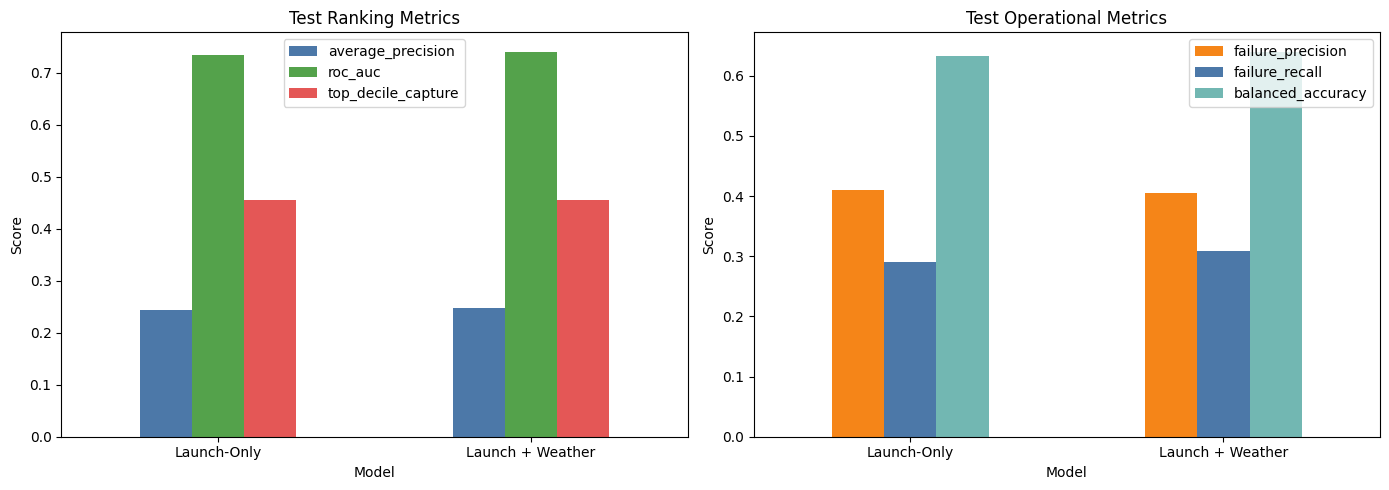

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ranking_plot_df = (
    final_test_metrics.loc[final_test_metrics["operating_point"] == "default_0_50", ["model", "average_precision", "roc_auc", "top_decile_capture"]]
    .set_index("model")
)
ranking_plot_df.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#54a24b", "#e45756"])
axes[0].set_title("Test Ranking Metrics")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=0)

threshold_plot_df = (
    final_test_metrics.loc[final_test_metrics["operating_point"] == "max_recall_at_precision_0.25", ["model", "failure_precision", "failure_recall", "balanced_accuracy"]]
    .set_index("model")
)
threshold_plot_df.plot(kind="bar", ax=axes[1], color=["#f58518", "#4c78a8", "#72b7b2"])
axes[1].set_title("Test Operational Metrics")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

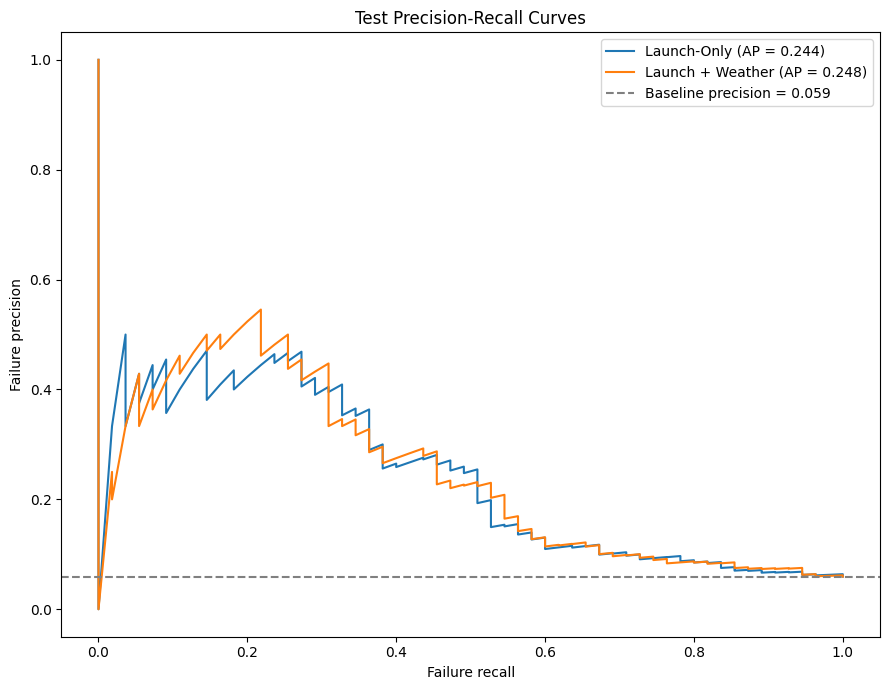

In [24]:
plt.figure(figsize=(9, 7))
for model_name, scores in test_scores.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)
    avg_precision = average_precision_score(y_test, scores)
    plt.plot(recall_curve, precision_curve, label=f"{model_name} (AP = {avg_precision:.3f})")

baseline_precision = y_test.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label=f"Baseline precision = {baseline_precision:.3f}")
plt.xlabel("Failure recall")
plt.ylabel("Failure precision")
plt.title("Test Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

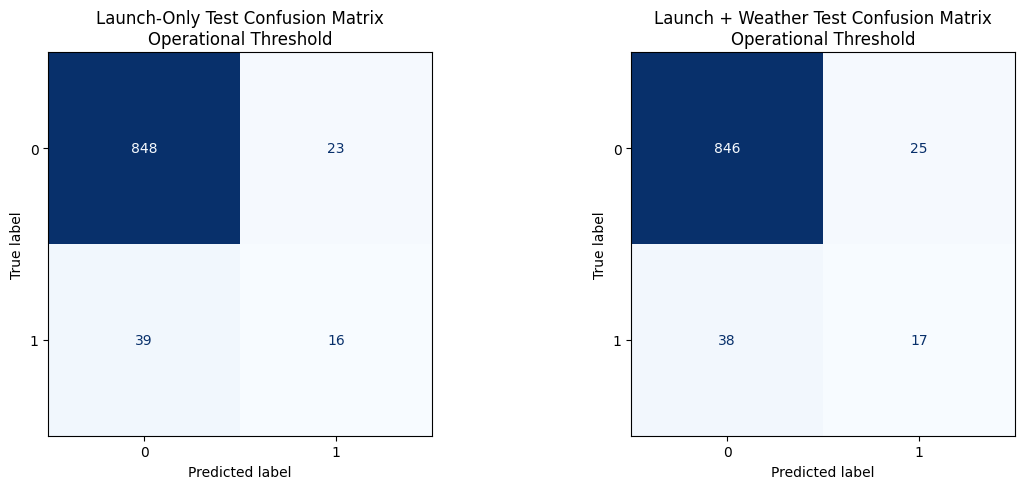

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (
        test_scores["Launch-Only"]
        >= validation_threshold_lookup[("Launch-Only", "max_recall_at_precision_0.25")]
    ).astype(int),
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
)
axes[0].set_title("Launch-Only Test Confusion Matrix\nOperational Threshold")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (
        test_scores["Launch + Weather"]
        >= validation_threshold_lookup[("Launch + Weather", "max_recall_at_precision_0.25")]
    ).astype(int),
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
)
axes[1].set_title("Launch + Weather Test Confusion Matrix\nOperational Threshold")

plt.tight_layout()
plt.show()

## Risk-Ranking Interpretation

A launch-failure model does not need to produce perfectly correct yes/no predictions to be
useful. In many practical settings, the more valuable use case is **risk ranking**:

- assign every launch a failure-risk score
- review or monitor the launches with the highest predicted risk more closely
- use the score to prioritize scarce engineering, weather, or operational attention

Under that use case, the important question is not only "did the model classify this launch
correctly at one threshold?" It is also:

- do launches with higher predicted failure probability actually fail more often?
- how many true failures are concentrated near the top of the model's ranking?

The next visuals answer those questions directly on the holdout test split.

In [26]:
def make_risk_bin_summary(y_true: pd.Series, scores: np.ndarray, model_name: str, n_bins: int = 10) -> pd.DataFrame:
    ranking_df = pd.DataFrame(
        {
            "actual_failure": y_true.to_numpy(),
            "predicted_failure_probability": scores,
        }
    ).sort_values("predicted_failure_probability", ascending=False).reset_index(drop=True)

    ranking_df["risk_decile"] = pd.qcut(
        ranking_df.index + 1,
        q=n_bins,
        labels=[f"Top {i}" for i in range(1, n_bins + 1)],
    )

    summary = (
        ranking_df.groupby("risk_decile", observed=False)
        .agg(
            launches=("actual_failure", "size"),
            observed_failure_rate=("actual_failure", "mean"),
            mean_predicted_failure_probability=("predicted_failure_probability", "mean"),
            failures_in_bin=("actual_failure", "sum"),
        )
        .reset_index()
    )

    summary["model"] = model_name
    summary["risk_rank_order"] = np.arange(1, len(summary) + 1)
    summary["cumulative_failures_captured"] = summary["failures_in_bin"].cumsum()
    summary["cumulative_failure_capture_rate"] = (
        summary["cumulative_failures_captured"] / summary["failures_in_bin"].sum()
    )
    summary["cumulative_launch_share"] = summary["launches"].cumsum() / summary["launches"].sum()

    metric_cols = [
        "observed_failure_rate",
        "mean_predicted_failure_probability",
        "cumulative_failure_capture_rate",
        "cumulative_launch_share",
    ]
    summary[metric_cols] = summary[metric_cols].round(4)

    return summary


risk_ranking_tables = pd.concat(
    [
        make_risk_bin_summary(y_test, test_scores["Launch-Only"], "Launch-Only"),
        make_risk_bin_summary(y_test, test_scores["Launch + Weather"], "Launch + Weather"),
    ],
    ignore_index=True,
)

risk_ranking_tables

,risk_decile,launches,observed_failure_rate,mean_predicted_failure_probability,failures_in_bin,model,risk_rank_order,cumulative_failures_captured,cumulative_failure_capture_rate,cumulative_launch_share
0,Top 1,93,0.2688,0.4964,25,Launch-Only,1,25,0.4545,0.1004
1,Top 2,93,0.0430,0.2917,4,Launch-Only,2,29,0.5273,0.2009
2,Top 3,92,0.0435,0.2393,4,Launch-Only,3,33,0.6000,0.3002
3,Top 4,93,0.0430,0.2109,4,Launch-Only,4,37,0.6727,0.4006
4,Top 5,92,0.0652,0.1834,6,Launch-Only,5,43,0.7818,0.5000
5,Top 6,93,0.0323,0.1628,3,Launch-Only,6,46,0.8364,0.6004
6,Top 7,92,0.0109,0.1431,1,Launch-Only,7,47,0.8545,0.6998
7,Top 8,93,0.0323,0.1212,3,Launch-Only,8,50,0.9091,0.8002
8,Top 9,92,0.0326,0.0991,3,Launch-Only,9,53,0.9636,0.8996
9,Top 10,93,0.0215,0.0630,2,Launch-Only,10,55,1.0000,1.0000


In [27]:
display(
    risk_ranking_tables.loc[
        :,
        [
            "model",
            "risk_decile",
            "launches",
            "mean_predicted_failure_probability",
            "observed_failure_rate",
            "failures_in_bin",
            "cumulative_failure_capture_rate",
        ],
    ]
)

,model,risk_decile,launches,mean_predicted_failure_probability,observed_failure_rate,failures_in_bin,cumulative_failure_capture_rate
0,Launch-Only,Top 1,93,0.4964,0.2688,25,0.4545
1,Launch-Only,Top 2,93,0.2917,0.0430,4,0.5273
2,Launch-Only,Top 3,92,0.2393,0.0435,4,0.6000
3,Launch-Only,Top 4,93,0.2109,0.0430,4,0.6727
4,Launch-Only,Top 5,92,0.1834,0.0652,6,0.7818
5,Launch-Only,Top 6,93,0.1628,0.0323,3,0.8364
6,Launch-Only,Top 7,92,0.1431,0.0109,1,0.8545
7,Launch-Only,Top 8,93,0.1212,0.0323,3,0.9091
8,Launch-Only,Top 9,92,0.0991,0.0326,3,0.9636
9,Launch-Only,Top 10,93,0.0630,0.0215,2,1.0000


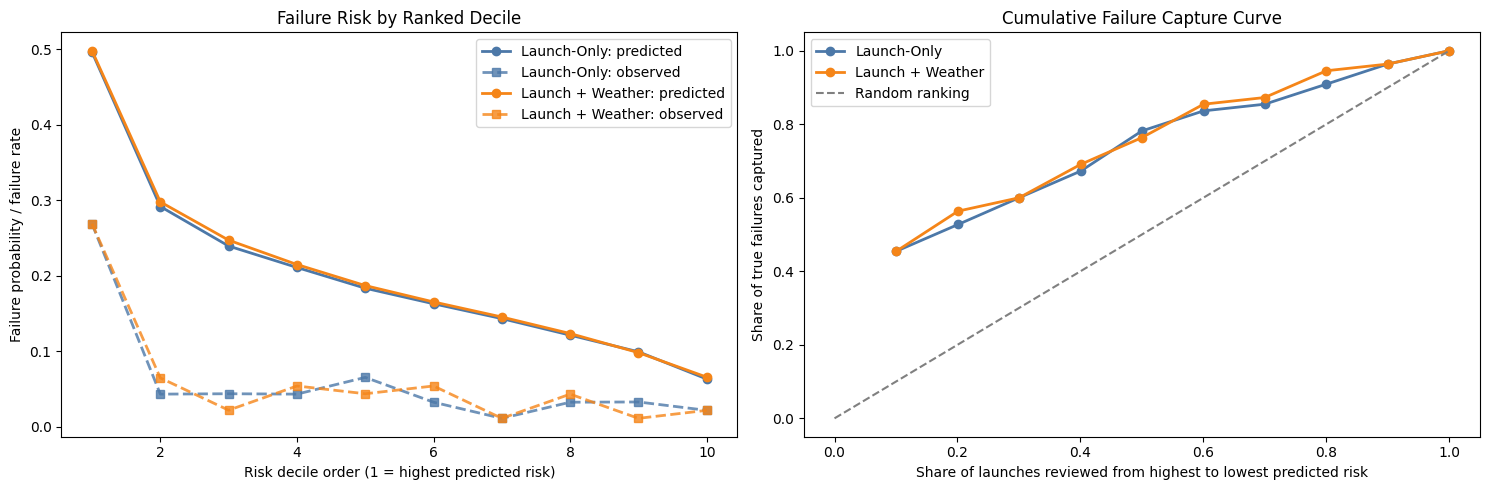

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for model_name, color in [("Launch-Only", "#4c78a8"), ("Launch + Weather", "#f58518")]:
    subset = risk_ranking_tables.loc[risk_ranking_tables["model"] == model_name].copy()
    axes[0].plot(
        subset["risk_rank_order"],
        subset["mean_predicted_failure_probability"],
        marker="o",
        linewidth=2,
        color=color,
        label=f"{model_name}: predicted",
    )
    axes[0].plot(
        subset["risk_rank_order"],
        subset["observed_failure_rate"],
        marker="s",
        linestyle="--",
        linewidth=2,
        color=color,
        alpha=0.8,
        label=f"{model_name}: observed",
    )

axes[0].set_title("Failure Risk by Ranked Decile")
axes[0].set_xlabel("Risk decile order (1 = highest predicted risk)")
axes[0].set_ylabel("Failure probability / failure rate")
axes[0].legend()

for model_name, color in [("Launch-Only", "#4c78a8"), ("Launch + Weather", "#f58518")]:
    subset = risk_ranking_tables.loc[risk_ranking_tables["model"] == model_name].copy()
    axes[1].plot(
        subset["cumulative_launch_share"],
        subset["cumulative_failure_capture_rate"],
        marker="o",
        linewidth=2,
        color=color,
        label=model_name,
    )

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random ranking")
axes[1].set_title("Cumulative Failure Capture Curve")
axes[1].set_xlabel("Share of launches reviewed from highest to lowest predicted risk")
axes[1].set_ylabel("Share of true failures captured")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation**

The risk-ranking view is one of the most important results in the notebook because it shows
why the models can still be useful even when their binary predictions are imperfect. The
overall failure rate in the test set is only **0.0594**. Yet in the highest-risk decile,
both models identify a group with an observed failure rate of **0.2688**, which is more
than four times the test-set baseline.

The predicted probabilities line up with that pattern. In the top decile, the
**Launch-Only** model assigns a mean predicted failure probability of **0.4964**, while the
**Launch + Weather** model assigns **0.4982**. The cumulative-capture curves tell the same
story from another angle: reviewing only the top 10% of launches by predicted risk captures
**45.45%** of all failures for both models.

This gives the final report a strong use-case argument. Even if the model is not accurate
enough to serve as an autonomous go/no-go rule, it can still support triage. A ranked risk
list can help an organization decide which launches deserve extra engineering review, which
cases should receive deeper weather scrutiny, and where limited expert attention is most
likely to uncover meaningful risk.

The two plots above support a ranking-based interpretation of usefulness:

- if the model is learning real failure signal, the top-ranked deciles should have higher
  observed failure rates than the bottom-ranked deciles
- if the cumulative-capture curve stays above the random baseline, then reviewing launches
  from highest predicted risk downward is more efficient than reviewing launches at random

That is important because a model can still be operationally useful even when it is not a
perfect binary classifier. For example, a risk score can still support:

- triage of launches that deserve extra engineering review
- prioritization of launches for more detailed weather and readiness checks
- allocation of expert attention to the small subset of launches where the model believes
  failure risk is highest

In that setting, the model's value comes from **ordering launches by relative risk**, not
from claiming that every high-risk launch will definitely fail.

## Feature Importance

The feature-importance views below help answer two final questions:

- does the launch-only model really rely on the split-safe historical features as expected?
- if weather is included, which weather features survive in the final narrowed weather model?

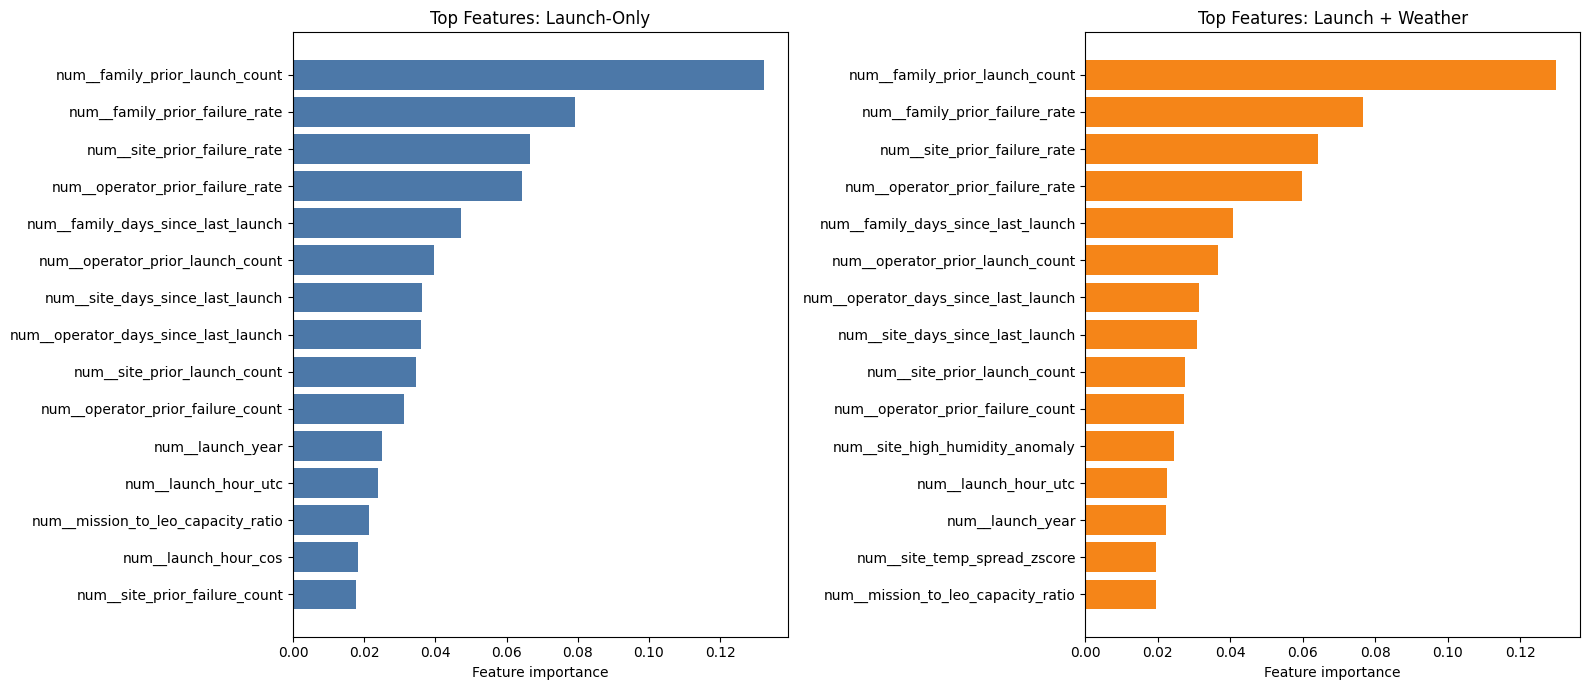

In [29]:
launch_importances = get_feature_importance_frame(final_models["Launch-Only"], top_n=15)
weather_importances = get_feature_importance_frame(final_models["Launch + Weather"], top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(
    launch_importances["feature"][::-1],
    launch_importances["importance"][::-1],
    color="#4c78a8",
)
axes[0].set_title("Top Features: Launch-Only")
axes[0].set_xlabel("Feature importance")

axes[1].barh(
    weather_importances["feature"][::-1],
    weather_importances["importance"][::-1],
    color="#f58518",
)
axes[1].set_title("Top Features: Launch + Weather")
axes[1].set_xlabel("Feature importance")

plt.tight_layout()
plt.show()

**Interpretation**

The feature-importance plots help connect the final scores back to the modeling choices. The
main question to ask when reading these charts is whether the strongest features come from
broad historical launch context or from the added weather variables.

The broader modeling process suggests a clear answer: family, operator, and site history
features provide the foundation of the model, while weather acts more like an incremental
adjustment. That interpretation is consistent with the final performance results. The launch
block alone already produces a strong ranking model, and the compact weather subset only
nudges the final metrics upward.

This is useful report context because it explains why weather matters without exaggerating
it. The findings are not that weather dominates launch risk, but that site-relative weather
conditions can add a small amount of extra signal once the stronger historical launch
context has already been captured.

## Final Interpretation

This notebook provides the cleanest final answer to the project's core comparison:

- how strong is the best **launch-only** failure model?
- does adding the selected weather subset improve the model enough to justify the extra
  complexity?

The answer depends on whether we look at validation or the untouched test split. On
validation, the launch-only model is the stronger ranking model, with **average precision =
0.3225** and **ROC AUC = 0.7761**, compared with **average precision = 0.3177** and
**ROC AUC = 0.7627** for the compact launch + weather model. That validation result is
why the notebook avoids overstating the role of weather.

On the holdout test split, the compact weather model has the modest overall edge. It reaches
**average precision = 0.2478** and **ROC AUC = 0.7405**, compared with **average precision =
0.2440** and **ROC AUC = 0.7340** for launch-only. It also improves default-threshold
failure recall from **0.2727** to **0.3091** while keeping failure precision nearly unchanged.

The practical conclusion is therefore measured: historical launch context remains the main
source of signal, while the selected site-relative weather variables add a small amount of
incremental value. Both final models are more compelling as risk-ranking and triage tools
than as hard binary launch-decision rules.


## Summary

This final notebook uses a chronology-aware random-forest workflow with:

- failure-oriented evaluation
- row-wise launch feature engineering
- split-safe historical reliability features
- validation-based weather subset selection
- validation-based operating-threshold selection
- explicit interpretation of the model as a launch-risk ranking tool

The main result is a close comparison between a strong launch-only model and a compact
launch + weather model. The launch-only model is stronger on validation, but the final
weather-augmented model has the modest edge on the untouched test split after the weather
block is narrowed to five site-relative variables.

A concise bottom line for the report is:

- the launch-only model remains simpler and highly competitive
- the final launch + weather model is the strongest holdout test model by ROC AUC, average
  precision, balanced accuracy, F1, and failure recall
- the weather lift is small, so historical launch context should be treated as the foundation
  of the model
- both models are more useful for prioritizing launches by relative risk than for making
  perfect yes/no failure predictions
